# Implementation of Castability Through Translation or Rotation

In [168]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, FancyArrow, FancyArrowPatch, Circle
import polygenerator as pg
import seaborn as sns
from sklearn.preprocessing import normalize

sns.set_style('whitegrid')

## Setting up helper functions

In [169]:
x = np.array([0, 0.5, 1])
y = np.array([1, 0, 1])

poly1 = np.column_stack([x, y])
poly1

array([[0. , 1. ],
       [0.5, 0. ],
       [1. , 1. ]])

In [170]:
rand_poly = np.array(pg.random_polygon(8))

In [171]:
def plot_polygon(polygon):
    poly = None
    if isinstance(polygon, Polygon):
        poly = polygon
    else:
        poly = Polygon(polygon, facecolor='lightgray',
                       alpha=0.9, edgecolor='black')

    ax = plt.subplot()
    fill_shape = np.array([(1, 1), (1, 0), (0, 0), (0, 1)])
    fill_shape = np.concat([fill_shape, poly.get_xy()])
    fill_shape = Polygon(fill_shape, closed=True, color='pink', alpha=0.5)

    ax.add_patch(fill_shape)
    ax.add_patch(poly)

    plt.show()

In [172]:
def get_edges(points):
    if isinstance(points, Polygon):
        return np.stack((points.get_xy(), np.roll(points.get_xy(), -1, axis=0)), axis=1)[:-1]
    else:
        return np.stack((points, np.roll(points, -1, axis=0)), axis=1)[:-1]
    

In [173]:
def get_perp_angle(edge):
    x = edge[1, 0] - edge[0, 0]
    y = edge[1, 1] - edge[0, 1]
    
    if x > 0:
        return np.arctan(y/x) + np.pi/2
    else:
        return np.arctan2(y,x) + np.pi/2

In [174]:
def get_angle(edge):
    x = edge[1, 0] - edge[0, 0]
    y = edge[1, 1] - edge[0, 1]
    
    if x > 0:
        return np.arctan(y/x)
    else:
        return np.arctan2(y,x)

In [175]:
def get_angle_bounds(angle):
    lower = angle-np.pi/2
    
    upper = angle+np.pi/2
    
    return (lower, upper)

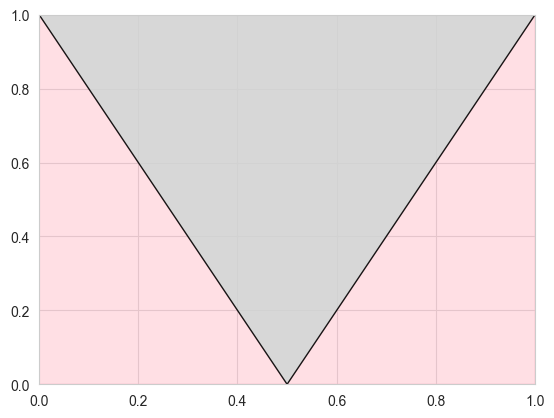

In [176]:
plot_polygon(poly1)

# Translatable Polygon

In [177]:
def translatable(poly1):

    poly1_edges = get_edges(poly1)

    angle_boundaries = np.empty((len(poly1_edges), 2))
    for i, edge in enumerate(poly1_edges):
        angle_boundaries[i] = get_angle_bounds(get_perp_angle(edge))

    min_angle = 0
    max_angle = np.pi

    for lower, upper in angle_boundaries:
        if min_angle > upper or max_angle < lower or min_angle > max_angle:
            return -1
        
        if min_angle < lower:
            min_angle = lower

        if max_angle > upper:

            max_angle = upper

    theta = (min_angle+max_angle)/2

    return (np.round(np.cos(theta), 3)/2, np.round(np.sin(theta), 3)/2)

In [178]:
def plot_translated(polygon):
    translation_vector = translatable(polygon)

    if translation_vector == -1:
        print("Not translatable!")
        return -1

    translated = polygon.copy()

    for i in range(len(translated)):
        translated[i] = translated[i] + translation_vector

    ax = plt.subplot()

    fill_shape = np.array([(1, 1), (1, 0), (0, 0), (0, 1)])
    fill_shape = np.concat([fill_shape, polygon])
    fill_shape = Polygon(fill_shape, closed=True, color='pink', alpha = 0.5)

    ax.add_patch(fill_shape)
    ax.add_patch(Polygon(polygon, fill=False, edgecolor='black',
                 linestyle='--', linewidth=2))
    ax.add_patch(Polygon(translated, facecolor = 'lightgray', alpha = 0.9, edgecolor = 'black', lw = 1))

    center_x, center_y = np.mean(polygon, axis=0)

    arrow = FancyArrow(
        center_x, center_y, translation_vector[0], translation_vector[1], color='black', head_width=0.02, width=0.005)
    ax.add_patch(arrow)

    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.05, 1.6)

## Demonstration: Triangle

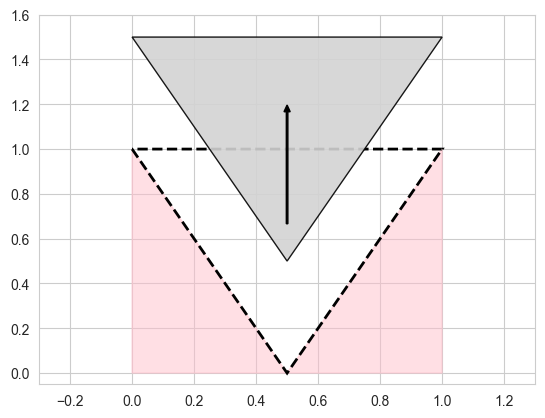

In [179]:
plot_translated(poly1)

## Demonstration: Not translatable nor rotatable (poly2)

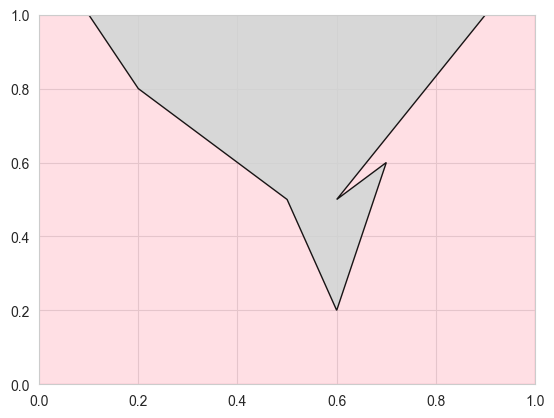

In [180]:
poly2 = np.array([
                    [0.1, 1], 
                    [0.2, 0.8],
                    [0.5, 0.5],
                    [0.6, 0.2],
                    [0.7, 0.6],
                    [0.6, 0.5],
                    [0.9, 1]
                ])

plot_polygon(poly2)

In [181]:
plot_translated(poly2)

Not translatable!


-1

## Demonstration: Only Translatable (from class)

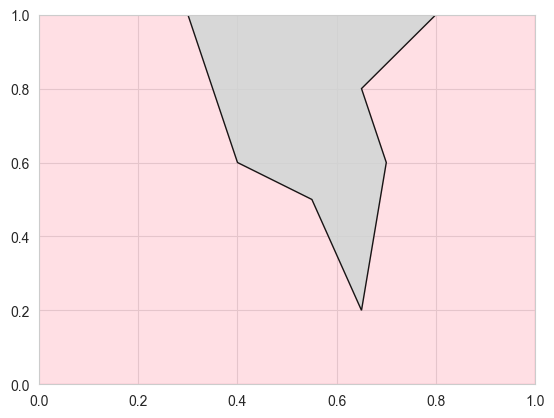

In [182]:
poly3 = np.array([
                    [0.3, 1], 
                    [0.4, 0.6],
                    [0.55, 0.5],
                    [0.65, 0.2],
                    [0.7, 0.6],
                    [0.65, 0.8],
                    [0.8, 1]
                ])

plot_polygon(poly3)

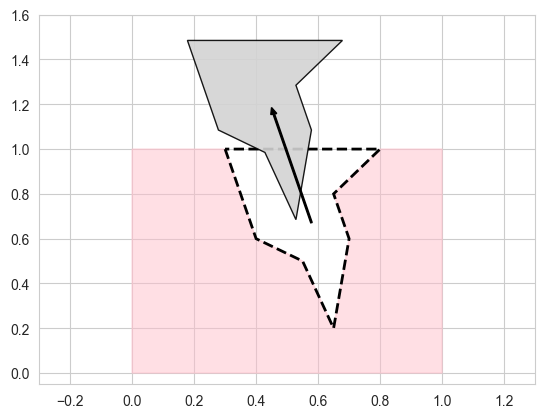

In [183]:
plot_translated(poly3)

## Demonstration: Parallelogram

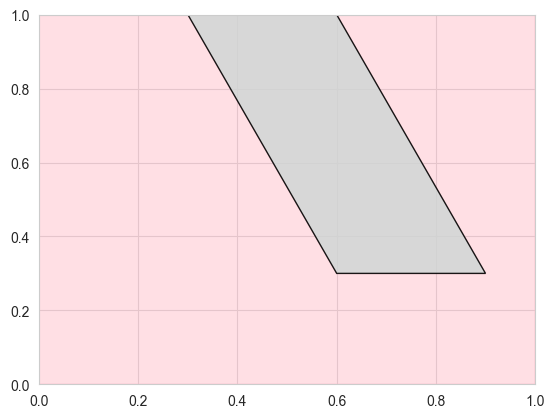

In [184]:
poly4 = np.array([
                    [0.3, 1], 
                    [0.6, 0.3],
                    [0.9, 0.3],
                    [0.6, 1]
                ])

plot_polygon(poly4)

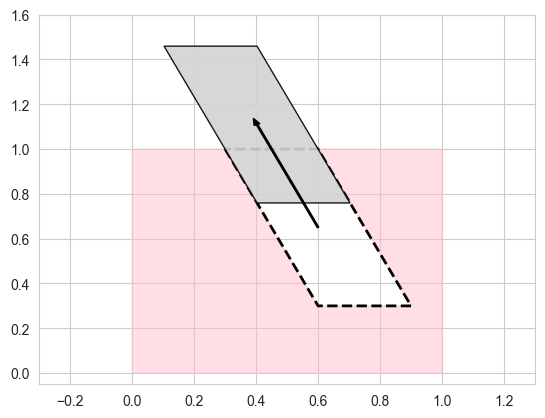

In [185]:
plot_translated(poly4)

## Demonstration: Only Rotatable (Half-Crescent)

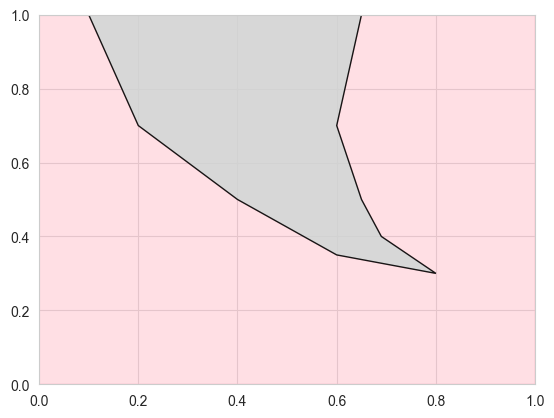

Not translatable!


-1

In [186]:
poly5 = np.array([[0.1,1],
                  [0.2,0.7],
                  [0.4, 0.5],
                  [0.6, 0.35],
                  [0.8, 0.3],
                  [0.69, 0.4],
                  [0.65, 0.5],
                  [0.6, 0.7],
                  [0.65,1]])
plot_polygon(poly5)
plot_translated(poly5)

# Rotatable Polygon

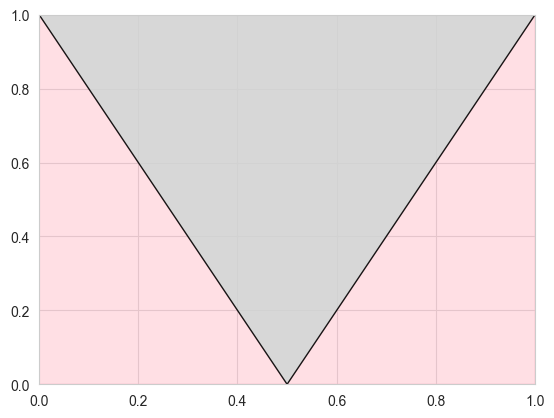

In [187]:
plot_polygon(poly1)

In [188]:
def rotatable_half_planes(polygon):
    edges = get_edges(polygon)
    # y (</>) Mx + B. Store sign (-1/1), M (slope, inf if vertical), and B (intercept)
    half_planes = np.empty(shape=(len(edges), 3))

    for i, edge in enumerate(edges):
        p1, p2 = edge[0], edge[1]
        dx, dy = p2 - p1
        angle = get_angle(edge)

        # 1. Vertical Constraint Case (Perpendicular is horizontal)
        if np.isclose(dy, 0):
            # If dx > 0, it's a right-facing constraint (x > p2[0])
            # If dx < 0, it's a left-facing constraint (x < p2[0])
            sign = 1 if dx > 0 else -1
            half_planes[i] = sign, np.inf, p2[0]
            continue

        # 2. Sloped Constraint Case
        # Perpendicular slope (m_perp) is -dx / dy
        m_perp = -dx / dy
        # Intercept b = y - mx
        b = p2[1] - m_perp * p2[0]

        if 0 < angle < np.pi:
            # y > mx + b (Sign 1)
            half_planes[i] = 1, m_perp, b
        else:
            # y < mx + b (Sign -1)
            half_planes[i] = -1, m_perp, b

    return half_planes

In [189]:
def find_point(half_planes):
    p = [0, 0]

    def point_on_plane(x, y, sign, m, b):
        if not np.isinf(m):
            return y > m*x + b if sign == 1 else y < m*x + b
        else:
            return x > b if sign == 1 else x < b

    def intersect(m1, b1, m2, b2):
        # Finds intersection of two lines

        if m1 == m2:
            return None  # Parallel
        if np.isinf(m1):
            return np.array([b1, m2*b1 + b2])
        if np.isinf(m2):
            return np.array([b2, m1*b2 + b1])
        x = (b2 - b1) / (m1 - m2)
        y = m1 * x + b1
        return np.array([x, y])

    for i in range(len(half_planes)):
        sign, m, b = half_planes[i]

        x, y = p

        if not point_on_plane(x, y, sign, m, b):
            point_found = False

            # Case 1: First constraint violated, just pick any point on its line
            if i == 0:
                p = np.array([0.0, b]) if not np.isinf(
                    m) else np.array([b, 0.0])
                continue

            for j in range(i):
                sign_prev, m_prev, b_prev = half_planes[j]
                new_p = intersect(m, b, m_prev, b_prev)

                if new_p is not None:
                    # Check if this intersection satisfies ALL constraints up to i
                    is_valid = True
                    for k in range(i + 1):
                        s_k, m_k, b_k = half_planes[k]
                        # Adding a small epsilon tolerance for float precision
                        if not point_on_plane(new_p[0], new_p[1], s_k, m_k, b_k - 1e-9 if s_k == 1 else b_k + 1e-9):
                            is_valid = False
                            break
                    if is_valid:
                        p = new_p
                        point_found = True
                        break


            if not point_found:
                print("No feasible intersection found.")
                return None

    return p

Obtains the half-planes from all the edges and shuffles their order before determining a valid pivot point

In [190]:
def rotatable(polygon, angle=np.pi/6):
    half_planes = rotatable_half_planes(polygon)
    np.random.shuffle(half_planes)
    valid_point = find_point(half_planes)

    if valid_point is None:
        print('Not rotatable!')
        return None
    else:
        print(f"Possible pivot at ({valid_point[0]}, {valid_point[1]})")

    # Center, Rotate, and Translate back
    centered = polygon - valid_point
    rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                                [np.sin(angle),  np.cos(angle)]])

    rotated = np.dot(centered, rotation_matrix) + valid_point

    return {
        "valid_point": valid_point,
        "rotated_poly": rotated,
        "half_planes": half_planes
    }

In [191]:
def plot_rotatable_result(polygon, result, padding=0.5):
    if result is None:
        return

    pivot = result["valid_point"]
    rotated = result["rotated_poly"]
    half_planes = result["half_planes"]

    # 1. Calculate Dynamic Limits
    # Combine all points that must be visible
    all_points = np.vstack([polygon, rotated, pivot])

    x_min, y_min = np.min(all_points, axis=0) - padding
    x_max, y_max = np.max(all_points, axis=0) + padding

    # Ensure a square-ish aspect ratio by taking the larger spread
    lower_lim = min(x_min, y_min)
    upper_lim = max(x_max, y_max)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect('equal')
    ax.set_xlim(lower_lim, upper_lim)
    ax.set_ylim(lower_lim, upper_lim)

    # 2. Plotting Half-Planes
    alpha, color = 0.1, 'green'
    for sign, m, b in half_planes:
        if np.isinf(m):
            y_range = [lower_lim, upper_lim]
            if sign == 1:  # x > b
                ax.fill_betweenx(y_range, b, upper_lim,
                                 alpha=alpha, color=color)
            else:         # x < b
                ax.fill_betweenx(y_range, lower_lim, b,
                                 alpha=alpha, color=color)
        else:
            x_vals = np.linspace(lower_lim, upper_lim, 2)
            y_vals = m * x_vals + b

            if sign == 1:  # y > mx + b
                ax.fill_between(x_vals, y_vals, upper_lim,
                                alpha=alpha, color=color)
            else:         # y < mx + b
                ax.fill_between(x_vals, lower_lim, y_vals,
                                alpha=alpha, color=color)

    # 3. Plotting Polygons
    fill_shape = np.array([[1, 1], [1, 0], [0, 0], [0, 1]])

    ax.add_patch(
        Polygon(np.concat([fill_shape, polygon]), facecolor='pink',
                         edgecolor='black', linewidth=2, alpha=1))
    ax.add_patch(Polygon(polygon, fill=False, edgecolor='black',
                         linestyle='--', linewidth=2))
    ax.add_patch(Polygon(rotated, facecolor='lightgray', alpha=0.9,
                         edgecolor='black', lw=2))

    # Rotation Point
    ax.plot(pivot[0], pivot[1], 'ro', markersize=8)
    original_center = np.mean(polygon, axis = 0)
    rotated_center  = np.mean(rotated, axis = 0)
    
    # Rotation Arrow (this is really complicated)
    radius = np.hypot(original_center[0] - pivot[0], original_center[1] - pivot[1])
    
    angle1 = np.degrees(np.arctan2(original_center[1] - pivot[1], original_center[0] - pivot[0]))
    angle2 = np.degrees(np.arctan2(rotated_center[1] - pivot[1], rotated_center[0] - pivot[0]))
    
    conn = f"arc3,rad=-0.2"
    # 2. Create the arrow patch
    # 'rad' creates the curvature. You may need to adjust this 
    # based on whether you want a clockwise or counter-clockwise arc.
    arc = FancyArrowPatch(
        original_center, rotated_center, 
        connectionstyle=conn, 
        arrowstyle='->', 
        mutation_scale=20, 
        color='black'
    )
    
    ax.add_patch(arc)

    plt.show()

## Demonstration: Triangle

Possible pivot at (1.75, 0.625)


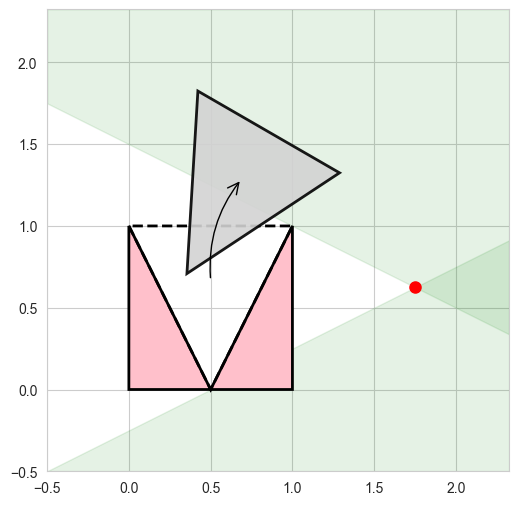

In [192]:
plot_rotatable_result(poly1, rotatable(poly1))

## Demonstration: Not translatable nor rotatable

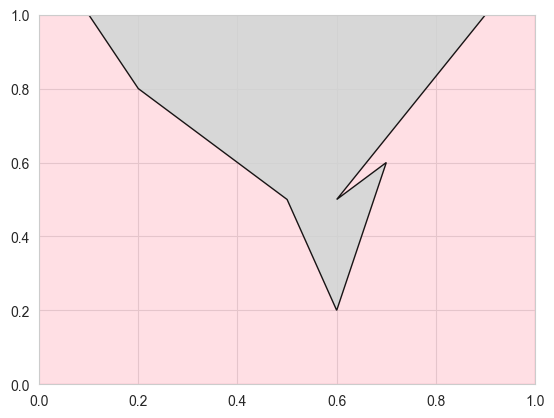

No feasible intersection found.
Not rotatable!


In [193]:
plot_polygon(poly2)
rotatable(poly2)

## Demonstration: Only Translatable (from class)

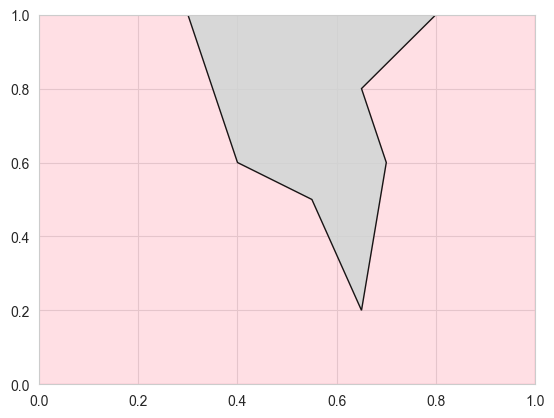

No feasible intersection found.
Not rotatable!


In [194]:
plot_polygon(poly3)
rotatable(poly3)

## Demonstration: Parallelogram

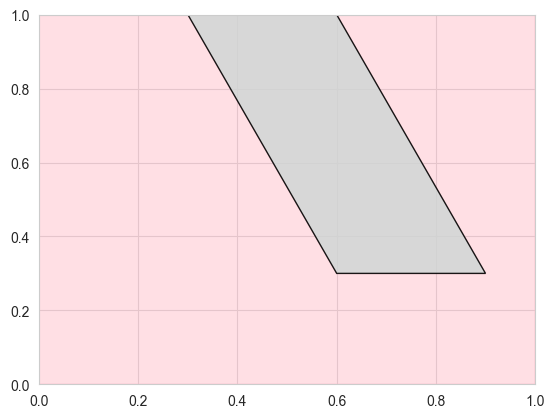

No feasible intersection found.
Not rotatable!


In [195]:
plot_polygon(poly4)
rotatable(poly4)

## Demonstration: Only Rotatable (Half-Crescent)

Possible pivot at (1.1584210526315788, 0.9152631578947368)


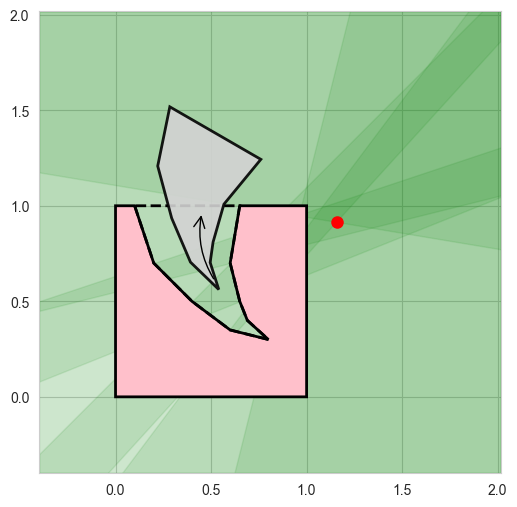

In [196]:
plot_rotatable_result(poly5, rotatable(poly5))